<a href="https://colab.research.google.com/github/Augista/MedicalImagingPneumonia/blob/main/MedicalImagingLungXray.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow numpy matplotlib pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 751.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 122.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.2 MB/s eta 0:00:00


In [ ]:
import os
import io
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


# **Menyiapkan Dataset**

In [ ]:
uploaded = files.upload()

Saving Lung X-Ray.zip to Lung X-Ray.zip


In [ ]:
import zipfile
import io

for fname in uploaded.keys():
    with zipfile.ZipFile(io.BytesIO(uploaded[fname]), 'r') as z:
        z.extractall("/content/dataset")


In [ ]:
import os

data_dir = "/content/dataset/Lung X-Ray Image/Lung X-Ray Image"

for cls in os.listdir(data_dir):
    cls_path = os.path.join(data_dir, cls)
    if os.path.isdir(cls_path):
        print(cls, ":", len(os.listdir(cls_path)))


Lung_Opacity : 1125
Viral Pneumonia : 1100
Normal : 1250


# **Data generator splitting named**

In [ ]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2
)

train_gen = train_datagen.flow_from_directory(
    data_dir,
    target_size = (224,224),
    batch_size = 32,
    class_mode = "categorical",
    subset = "training"
)

val_gen = train_datagen.flow_from_directory(
    data_dir,
    target_size = (224,224),
    batch_size = 32,
    class_mode = "categorical",
    subset = "validation"
)

print(train_gen.class_indices)


Found 2780 images belonging to 3 classes.
Found 695 images belonging to 3 classes.
{'Lung_Opacity': 0, 'Normal': 1, 'Viral Pneumonia': 2}


# **DATA AUGMENTATION**

In [ ]:
augment_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 15,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    zoom_range = 0.1,
    horizontal_flip = True,
    fill_mode = "nearest",
    validation_split=0.2
)

train_aug = augment_datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_aug = augment_datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)


Found 2780 images belonging to 3 classes.
Found 695 images belonging to 3 classes.


# **Model CNN**

In [ ]:
num_classes = len(train_gen.class_indices)

model = Sequential([

    Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer = Adam(1e-4),
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,243 (42.61 MB)

 Trainable params: 11,169,795 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

# **Training**

In [ ]:
history = model.fit(
    train_aug,
    epochs = 5,
    validation_data = val_aug
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.6540 - loss: 1.4820 - val_accuracy: 0.3237 - val_loss: 5.1748
Epoch 2/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.7518 - loss: 0.6055 - val_accuracy: 0.3237 - val_loss: 10.3139
Epoch 3/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.7648 - loss: 0.5645 - val_accuracy: 0.3252 - val_loss: 12.0632
Epoch 4/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.7868 - loss: 0.4954 - val_accuracy: 0.3424 - val_loss: 7.8934
Epoch 5/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.8023 - loss: 0.4494 - val_accuracy: 0.3482 - val_loss: 5.6631


## Testing by Image

In [ ]:
test_img = files.upload()

Saving penudsfe.jpg to penudsfe.jpg


# **Prediksi dan menampilkan Hasil prediksi**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


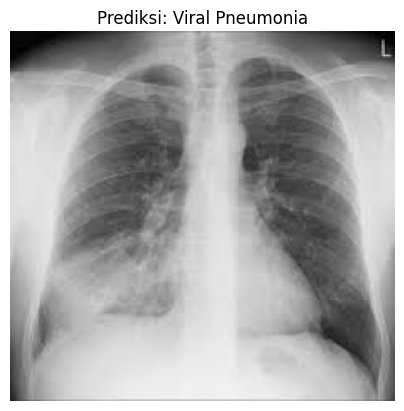

In [ ]:
for fname in test_img.keys():
    img = Image.open(io.BytesIO(test_img[fname])).convert("RGB")
    img_resized = img.resize((224,224))

    x = np.array(img_resized)/255.0
    x = np.expand_dims(x, axis=0)

    pred = model.predict(x)
    class_index = np.argmax(pred)

    labels = list(train_gen.class_indices.keys())
    label_pred = labels[class_index]

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediksi: {label_pred}")
    plt.show()
